### JAX Tutorial for Students

# Introduction
"""
JAX is a library for array-oriented numerical computation (similar to NumPy), with automatic differentiation and JIT compilation to enable high-performance machine learning research.

This notebook provides an overview of essential JAX features so you can get started with JAX quickly:

- JAX provides a unified NumPy-like interface to computations that run on CPU, GPU, or TPU, in local or distributed settings.
- JAX features built-in Just-In-Time (JIT) compilation via Open XLA, an open-source machine learning compiler ecosystem.
- JAX functions support efficient evaluation of gradients via its automatic differentiation transformations.
- JAX functions can be automatically vectorized to efficiently map them over arrays representing batches of inputs.
"""

# 1. JAX's Syntax is Strikingly Similar to NumPy's

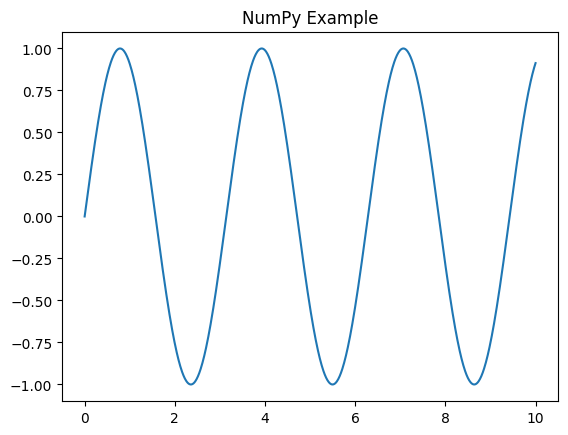

In [1]:
## NumPy Example
import numpy as np
import matplotlib.pyplot as plt

# Generate data using NumPy
x_np = np.linspace(0, 10, 1000)
y_np = 2 * np.sin(x_np) * np.cos(x_np)

# Plot the results
plt.plot(x_np, y_np)
plt.title("NumPy Example")
plt.show()

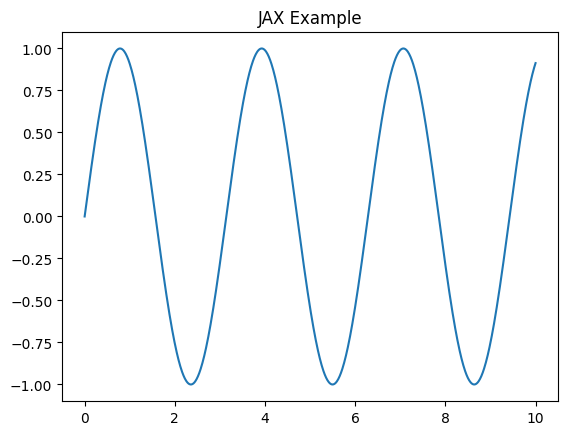

In [2]:
## JAX Example
import jax.numpy as jnp

# Generate data using JAX
x_jnp = jnp.linspace(0, 10, 1000)
y_jnp = 2 * jnp.sin(x_jnp) * jnp.cos(x_jnp)

# Plot the results
plt.plot(x_jnp, y_jnp)
plt.title("JAX Example")
plt.show()

## Observations
- Both libraries use a similar syntax for array operations.
- JAX arrays can be used in place of NumPy arrays in many scenarios with minor changes.

# 2. JAX Arrays Are Immutable

In NumPy, arrays are mutable. In JAX, arrays are immutable, meaning you cannot directly modify their contents.
Instead, JAX provides functional updates using `.at[]` methods.



In [3]:
# NumPy Example
x_np = np.array([1, 2, 3, 4])
x_np[2] = 99
print("Modified NumPy Array:", x_np)

# JAX Example
x_jnp = jnp.array([1, 2, 3, 4])
y_jnp = x_jnp.at[2].set(99)

print("Original JAX Array:", x_jnp)
print("Modified JAX Array:", y_jnp)

Modified NumPy Array: [ 1  2 99  4]
Original JAX Array: [1 2 3 4]
Modified JAX Array: [ 1  2 99  4]


# 3. JAX Transform Functions

## `jit()`

The `jit` function compiles your code using XLA and caches the compiled version for speed.

### Detailed Explanation of JIT
#### What Happens When You Run a Normal Python Function?
When you run a Python function, it goes through the following steps:
1. **Interpretation**:
   - The Python interpreter reads and parses the function line by line, converting the code into bytecode.
2. **Execution**:
   - The bytecode is executed by the Python Virtual Machine (PVM). Each line of code is interpreted at runtime, which can be slower because the interpreter translates instructions into machine code on the fly.

This approach is simple and flexible, but the overhead of interpretation can make Python slower compared to compiled languages like C or Fortran.

#### What Happens When You Use JIT in JAX?
When you apply JIT (`@jit`) to a function in JAX, the following sequence occurs:

1. **Static Analysis**:
   - When the function is called for the first time, JAX analyzes the function's code and determines its computation graph. This involves understanding the inputs and operations in the function.

2. **Compilation**:
   - The function is compiled using **XLA** (Accelerated Linear Algebra), a domain-specific compiler designed for optimizing machine learning workloads. This compilation converts the Python function into highly efficient machine code.

3. **Execution**:
   - Once compiled, the function is executed as machine code, bypassing Python's interpretation overhead.
   - Subsequent calls to the function reuse the cached compiled code, making them extremely fast.

#### Why Is This Important in Scientific Computing?
- **Speed**:
  - Scientific computations often involve large datasets and complex operations. JIT can significantly reduce computation time by eliminating Python's interpretation overhead.
- **Optimization**:
  - XLA performs advanced optimizations such as kernel fusion, loop unrolling, and constant folding, which are essential for efficient computation on modern hardware (e.g., GPUs, TPUs).
- **Portability**:
  - JIT allows the same code to run efficiently on different hardware backends, making it versatile for scientific applications.


In [4]:
import time

# Define a simple function
def compute(x):
    return jnp.sum(x ** 2)

x = jnp.ones(10000)

# Benchmark
start = time.time()
compute(x)  # First call
print("First call without jit:", time.time() - start)

start = time.time()
compute(x)  # Second call
print("Second call without jit:", time.time() - start)

First call without jit: 0.397475004196167
Second call without jit: 0.0010945796966552734


In [5]:
from jax import jit

@jit
def compute_jit(x):
    return jnp.sum(x ** 2)

# Benchmark
start = time.time()
compute_jit(x)  # First call (includes compilation)
print("First call with jit (compilation included):", time.time() - start)

start = time.time()
compute_jit(x)  # Second call (cached)
print("Second call with jit (cached):", time.time() - start)

First call with jit (compilation included): 0.37212228775024414
Second call with jit (cached): 0.0017631053924560547


## `vmap()`

The `vmap` function automatically vectorizes operations, allowing you to apply a function over batched inputs efficiently.

Vectorized Result: [ 1  4  9 16 25]


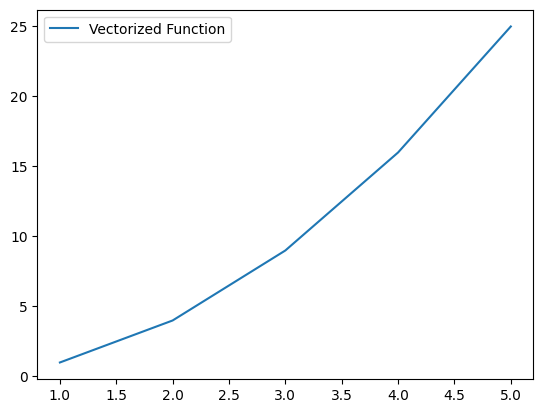

In [6]:
from jax import vmap

# Define a simple function
def f(x):
    return x ** 2

# Vectorize the function
batched_f = vmap(f)

# Apply to batched input
x = jnp.array([1, 2, 3, 4, 5])
result = batched_f(x)
print("Vectorized Result:", result)

# Plot the results
plt.plot(x, result, label="Vectorized Function")
plt.legend()
plt.show()

## `grad()`

The `grad` function computes gradients of a given function with respect to its inputs.

In [7]:
from jax import grad

# Define a simple function
def loss(x):
    return x ** 2

# Compute the gradient
grad_loss = grad(loss)

x = 3.0
print("Gradient at x=3:", grad_loss(x))

# Vectorized Gradient
x = jnp.array([1.0, 2.0, 3.0])
grad_batched = vmap(grad_loss)(x)
print("Gradients for array:", grad_batched)

Gradient at x=3: 6.0
Gradients for array: [2. 4. 6.]


# 4. Random Number Generation


Random number generation in JAX is based on a PRNG (Pseudo-Random Number Generator) model, where keys are immutable and must be explicitly managed.

In [8]:
from jax import random

# Initialize a key
key = random.PRNGKey(42)
print("Initial Key:", key)

# Generate random numbers
val1 = random.normal(key, shape=(1,))
print("Random Sample 1:", val1)

# Verify the key remains unchanged
print("Key After First Sample:", key)

# Generate random numbers
val2 = random.normal(key, shape=(1,))
print("Random Sample 1:", val2)

# Split the key to get a new state
key, subkey = random.split(key)
val2 = random.normal(subkey, shape=(1,))
print("Random Sample 2 (New Subkey):", val2)
print("Key After Splitting:", key)

Initial Key: [ 0 42]
Random Sample 1: [-0.02830462]
Key After First Sample: [ 0 42]
Random Sample 1: [-0.02830462]
Random Sample 2 (New Subkey): [0.60576403]
Key After Splitting: [1832780943  270669613]
